<a href="https://colab.research.google.com/github/ohta-ee-ous/Lecture_ImageProcessing/blob/main/%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86%E6%BC%94%E7%BF%92_6_%E3%83%91%E3%82%BF%E3%83%BC%E3%83%B3%E3%83%9E%E3%83%83%E3%83%81%E3%83%B3%E3%82%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
デジタル画像処理演習

#**パターンマッチング**

2026/06/08 改訂

---

この演習では、次の内容を学習します。

1. ハフ変換
1. 画像の類似度
1. テンプレートマッチング

次に書かれている「準備」から順番に進めていってください。

最後に[課題](#assignment)があります。

<a name="junbi"></a>
# **準備**

最初に準備を行います。次のコードを実行してください。

In [ ]:
#@title ⌨ 準備
# 外部モジュールを取り込む
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
from google.colab.patches import cv2_imshow
from ipywidgets import interact, IntSlider, FloatSlider

# ユーザーのディスプレイの解像度に合わせて画像の画面表示サイズを調整する
screen_resolution = output.eval_js('[window.screen.width, window.screen.height, screen.orientation.type]')
screen_scale = max(screen_resolution[:2])/1920
def show_image(img):
  if screen_scale >= 1.0:
    cv2_imshow(img)
  else:
    cv2_imshow(cv2.resize(img, None, fx=screen_scale, fy=screen_scale))

# 使用するデータをダウンロードする。
!wget -nc "https://github.com/ohta-ee-ous/Lecture_ImageProcessing/releases/download/v1.0.0/imagefiles.zip" -O imagefiles.zip
!unzip -nq imagefiles.zip
!rm -f imagefiles.zip
!if [[ -f "asagao.png" && -f "README.txt" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

「準備が完了しました。」と表示されれば成功です。
次のライブラリや関数が使えるようになっています。

|名称|説明|
|:---|:---|
|cv2|画像処理ライブラリ OpenCV|
|np|数値計算ライブラリ NumPy|
|plt|グラフ描画ライブラリ Matplotlib|
|cv2_imshow|Colab専用の画像表示関数|

画像ファイルも用意されています。Colab の画面の左端にある「ファイル」アイコン（📁の形）をクリックするとファイルブラウザが表示されて、ファイルの一覧を見ることができます。もう一度クリックすると非表示になります。  
自分のパソコンに保存してある画像ファイルを Colab で使いたい場合には、このファイルブラウザの中へ画像ファイルをドラッグ＆ドロップしてください。

<br>

# **1．ハフ変換**

ハフ（Hough）変換とは、2値画像の中から直線や円などの特定の形状を検出する手法です。検出結果は、直線や円の方程式のパラメータとして得られます。
例えば、直線検出の場合は、直線の方程式 $y=ax+b$ の $a$ と $b$ の値が得られます。

## 直線の検出

直線の検出を試してみましょう。

まず、次のコードを実行して原画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('bench.jpg')
show_image(src)

ハフ変換を行うためには、あらかじめ、画像をエッジ抽出した2値画像にしておく必要があります。  
この画像変換には Canny法がよく利用されます。

次のコードを実行してください。

In [ ]:
#@title ⌨ 2値の線図形に変換
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY) # グレイスケールに変換する
edge = cv2.Canny(gray, 50, 200) # Canny法によってエッジ画像を得る
show_image(edge)

Canny法では、輪郭が1画素の幅になります。

それでは、この画像の中にある直線を検出してみましょう。直線検出のハフ変換には `cv2.HoughLines`関数を利用します。  
直線の方程式には、傾き $a$ と y切片 $b$ を使う一般的な $y=ax+b$ の式ではなく、$\rho = x\cos\theta + y\sin\theta$ が使われます。
$\rho$は原点から直線へ下した垂線の長さ、$\theta$はその垂線の向きを表します。

<h3>使い方</h3>

*lines* = <tt>cv2.HoughLines</tt>( *src*, *rho*, *theta*, *threshold* )

- *src* : 入力画像の変数を与える。
- *roh* : $\rho$の検出精度を与える。（単位は画素）
- *theta* : $\theta$の検出精度を与える。（単位はラジアン）
- *threshold* : 投票値の閾値を与える。
- *lines* : 検出された直線の$\rho$, $\theta$の値を格納する変数を与える。

次のコードを実行してください。

In [ ]:
#@title ⌨ Hough変換で直線検出
lines = cv2.HoughLines(edge, 1, np.pi/180, 150)
# 検出した直線を描く
dst1 = cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR)
dst2 = src.copy()
#dst = edge.copy()
for rho, theta in lines.squeeze():
  a, b = np.cos(theta), np.sin(theta)
  x, y = int(a*rho), int(b*rho)
  m, n = int(1000*b), int(1000*a)
  cv2.line(dst1, (x-m, y+n), (x+m, y-n), (200, 255, 0), 1, cv2.LINE_AA )
  cv2.line(dst2, (x-m, y+n), (x+m, y-n), (200, 255, 0), 1, cv2.LINE_AA )
show_image(cv2.hconcat([dst1, dst2]))
print(len(lines.squeeze()),'本の直線を検出しました。')

ハフ変換によって画像から複数の直線を同時に検出することができます。画素値 1（白色）の画素の数が多い直線ほど検出されやすいです。

## ハフ変換の原理

直線検出のハフ変換の原理を見ていきます。

ハフ変換では、直線の方程式 $\rho = x\cos\theta + y\sin\theta$ に従って、2値画像における画素値1（白色）の画素の座標値 $x$, $y$ をもとに、
$\rho$-$\theta$パラメータ空間内に点をプロットします。

実際に画像で確認しましょう。

次のコードでは背景が画素値 $0$（黒色）の画像をつくり、座標 $(2,5)$の画素だけ $0$ 以外にします。この例では分かりやすいように点に色を付けることにします。  
コードを実行してください。

In [ ]:
#@title ⌨ 1点だけの図形
def show_image_plt(img):
  fig, ax = plt.subplots(dpi=80)           # 描画領域を準備
  ax.imshow(img, 'gray', vmin=0, vmax=255) # 画像を貼り付け
  ax.set_xlabel('$x$', fontsize=12)        # x軸のラベル
  ax.set_ylabel('$y$', fontsize=12)        # y軸のラベル
  ax.set_xticks([i for i in range(10)])    # x軸の数値
  ax.set_yticks([i for i in range(10)])    # y軸の数値
  ax.xaxis.tick_top()                      # x軸を上にする
  ax.xaxis.set_label_position('top')       # x軸のラベルを上にする

img = np.zeros((10, 10, 3), 'uint8') # 50x50のサイズで黒色の画像をつくる
x = 2
y = 5
img[y, x] = (255, 120, 50) # 座標(x,y)の画素値を(R,G,B)=(255,120,50)にする
show_image_plt(img)

この画像をもとにしてハフ変換の$\rho$-$\theta$パラメータ空間を作ります。
次のコードを実行してください。

In [ ]:
#@title ⌨ パラメータ空間を表示
def hough_space_view(img, cp=None):
  fig, ax = plt.subplots(dpi=80,figsize=(6,4))   # 描画領域のサイズを設定
  theta_values = np.linspace(0, np.pi, 181)
  for x in range(img.shape[0]):
    for y in range(img.shape[1]):
      color = img[y, x]        # 画素値を取り出す
      if np.any(color != 0):   # 色が黒以外であればrho,thetaを計算する
        p = []
        for theta in theta_values:
          rho = x * np.cos(theta) + y * np.sin(theta)
          p.append(rho)
        # パラメータ空間にプロットする
        ax.plot(p, color=list(color / 255))
  # パラメータ空間を表示する
  if cp is not None:
    for a, b in cp:
      x = int(np.rad2deg(np.atan2(-1, a)) + 180) % 180
      y = b/np.sqrt(a**2+1)
      plt.annotate(f'({x:.0f}, {y:.3f})', (x, y), xytext=(x-14, y-2), fontsize=13)
      ax.plot(x, y, 'o', color='red', markerfacecolor='none', markersize=13)
  ax.set_xticks(list(range(0, 181, 15)))
  ax.set_xlabel(r'$\theta$ (deg)', fontsize=12)           # x軸にラベルを表示
  ax.set_ylabel(r'$\rho$ (pixel)', fontsize=12)           # y軸にラベルを表示
  ax.grid()
  fig.tight_layout()

hough_space_view(img)

一つの曲線が描かれたグラフが表示されました。これが$\rho$-$\theta$パラメータ空間（2次元空間）で、横軸が$\theta$、縦軸が$\rho$になっています。

$\rho = x\cos\theta + y\sin\theta$ に、$x=2$、$y=5$ を代入すると
$$\begin{align}
\rho &= 2\cos\theta + 5\sin\theta\\
&= \sqrt{29}\sin(\theta+\alpha)~~~~\mbox{ただし、}\alpha = \tan^{-1}\frac{2}{5}
\end{align}$$
になります。$\rho$-$\theta$パラメータ空間に描かれたのはこのグラフです。

このように、画像の1つの点は、$\rho$-$\theta$パラメータ空間では1本の曲線になります。

画像上の点を増やしてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 直線に並んだ4点
img = np.zeros((10, 10, 3), 'uint8') # 50x50のサイズで黒色の画像をつくる
a = -1 # 直線の傾き
b =  7 # 直線のy切片
xs = [2, 3, 4, 6]
for x in xs:
  y = a*x + b
  img[y, x] = (295-x*20, 120, 50)
img[7, 8] = (120, 120, 120)
show_image_plt(img)

オレンジ色の4点が直線上に並んでいます。灰色の点はこの直線上にはない点です。

これを$\rho$-$\theta$パラメータ空間で表してみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ パラメータ空間を表示
hough_space_view(img,[[a, b]])

点と同じ数の曲線が描かれました。いくつかの場所で曲線が交わっていることが分かります。この中で最も多くの曲線が交わっているは $\theta=45^\circ$、$\rho=4.950$ の場所です。

この値を $\rho = x\cos\theta + y\sin\theta$ に代入してみると、
$$\begin{align}
4.950 &= x\cos 45^\circ + y\sin 45^\circ\\
4.950 &= \frac{1}{\sqrt{2}}x+\frac{1}{\sqrt{2}}y\\
y &= -x+4.950\sqrt{2}\\
\end{align}$$
<center>$4.950\sqrt{2}\simeq 7$ であるから</center>
$$y=-x+7$$

という直線の方程式が得られます。
オレンジ色の4点の座標は、左から$(2,5)$、$(3,4)$、$(4,3)$、$(6,1)$ですから、$y=-x+7$ はこの4点が含まれる直線の方程式として正しいですね。

このようにハフ変換では、パラメータ空間の中で曲線が多く交わっている点の座標から直線の方程式のパラメータを推測します。このとき、灰色の点のようにノイズが含まれていても交わる曲線の本数が少ないので、直線検出に影響することがありません。

画像内に直線が複数ある場合はどうでしょうか。次のコードを実行して画像を作成してください。

In [ ]:
#@title ⌨ 3本の直線
img = np.zeros((10, 10, 3), 'uint8') # 50x50のサイズで黒色の画像をつくる
lin = []
# 1本目
for x in range(1,10):
  img[-x+10, x] = (255, 120, 50)
lin.append([-1, 10])
# 2本目
for x in range(4,10):
  img[x-4, x] = (0, 160, 190)
lin.append([1, -4])
# 3本目
for x in range(10):
  img[8, x] = (100, 200, 100)
lin.append([0, 8])

show_image_plt(img)

3本の直線があります。
次のコードを実行してパラメータ空間を作りましょう。

In [ ]:
#@title ⌨ パラメータ空間を表示
hough_space_view(img, lin)

ちょっと見づらいですが、曲線が多く交わる場所が3箇所あることが分かります。

ハフ変換を行うときは、交わる曲線の本数をしきい値として与えます。そして、しきい値以上の本数が交わっている場所の$\rho$と$\theta$の組をすべて見つけ出すことによって、複数の直線を検出することができます。



## 円の検出

ハフ変換は方程式で表現できる図形であれば、直線以外にも利用できます。
それでは円検出のハフ変換を見てみましょう。

次のコードを実行して、原画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('coins.jpg')
show_image(src)

円検出には、`cv2.HoughCircles`関数を利用します。  
円の方程式は、$(x-a)^2+(y-b)^2=r^2$ です。パラメータは$a$、$b$、$r$の3つですので、円検出のハフ変換のパラメータ空間は3次元空間になります。

<h3>使い方</h3>

*circles* = <tt>cv2.HoughCircles</tt>( *src*, *method*, *dp*, *minDist*, *circles*, *param1*, *param2*, *minRadius*, *maxRadium* )

- *src* : 入力画像の変数を与える。
- *method* : 円の検出手法を指定する。
- *dp* : 入力画像とアキュームレーターの解像度比を与える。
- *minDist* : 検出する円の中心点間の最小距離を与える。
- *param1*, *param2* : *method*で使用する固有のパラメータ。
- *minRadius* : 検出する円の最小半径を与える。
- *maxRadius* : 検出する円の最大半径を与える。
- *circles* : 検出した円の中心座標と半径を格納する変数を与える。

`cv2.HoughCircles`関数の入力画像にはグレイスケール画像を与えます。エッジ検出は、`cv2.HoughCiclrs`関数の中で行われますので、Canny法でエッジ検出する必要はありません。

次のコードを実行してください。

In [ ]:
#@title ⌨ 円の検出
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY) # グレイスケールに変換
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, 40, None, 100, 60, 30, 80)
# 検出した円を描く
dst = src.copy()
for a, b, r in circles[0]:
  cv2.circle( dst, (int(a), int(b)), int(r), (255, 100, 255), 2, cv2.LINE_AA)
show_image( dst )
print(len(circles[0]),'個の円を検出しました。')

望み通りの検出結果を得るには`cv2.HoughCircles`関数に与えるパラメータ値の調整が必要です。パラメータの数が多いので、この調整がやや難しいです。

<br>

# **2．画像の類似度**

2枚の画像における同一座標の画素値を用いて、画像間の類似性を測ることができます。

類似性を表す尺度として、代表的なものに次の4つがあります。
- 差分絶対値和 SAD (Sum of Absolute Difference)
- 差分二乗和 SSD (Sum of Squared Difference)
- 正規化相互相関 NCC (Normalized Cross-Correlation)
- ゼロ平均正規化相互相関 ZNCC (Zero-mean Normalized Cross-Correlation)

画像 $f$ と画像 $g$ のサイズが同じとき、次の計算で求められます。

<h4>差分絶対値和</h4>
$$\mathrm{SAD}=\sum_y\sum_x |f(x,y)-g(x,y)|$$

<h4>差分二乗和</h4>
$$\mathrm{SSD}=\sum_y\sum_x(f(x,y)-g(x,y))^2$$


<h4>正規化相互相関</h4>
$$\mathrm{NCC}=\frac{\sum_y\sum_x f(x,y)g(x,y)}{\sqrt{\sum_y\sum_x f(x,y)^2}\sqrt{\sum_y\sum_x g(x,y)^2}}$$

<h4>ゼロ平均正規化相互相関</h4>
$$\mathrm{ZNCC}=\frac{\sum_y\sum_x \left(f(x,y)-\bar{f}\right)\left(g(x,y)-\bar{g}\right)}{\sqrt{\sum_y\sum_x \left(f(x,y)-\bar{f}\right)^2}\sqrt{\sum_y\sum_x \left(g(x,y)-\bar{g}\right)^2}}$$
<br>
<center>ただし、$\bar{f}$は全ての$f(x,y)$の平均、$\bar{g}$は全ての$g(x,y)$の平均</center>



2画像の類似性の尺度を計算する場合は、`cv2.matchTemplate`関数が利用できます。

<h4>使い方</h4>

*result* = <tt>cv2.matchTemplate</tt>( *image*, *templ*, *method* )

- *image* : 1枚目の画像を与える。（対象画像）
- *templ* : 2枚目の画像を与える。（テンプレート画像）
- *method* : 類似性の計算手法を指定する
  - `cv2.TM_SQDIFF` : 差分二乗和
  - `cv2.TM_CCORR_NORMED` : 正規化相互相関
  - `cv2.TM_CCOEFF_NORMED` : ゼロ平均正規化相互相関
- *result* : 計算結果を格納する変数を与える。

類似性の計算を試してみましょう。

次のコードを実行して画像を読み込んでください。画像はグレイスケールに変換しておきます。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('magamo.png')
img1 = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY).astype('float32') # 実数型のグレイスケール画像に変換
show_image(img1)

この画像にノイズを加えた画像と元の画像とで、SSD、NCC、ZNCC を計算してみます。

次のコードを実行するとノイズの強度を設定するスライダーが表示されます。画像の下にはSSD、NCC、ZNCCの値が表示されます。スライダーを動かして、類似性の値がそれぞれどのような値に変わるのかを見てみましょう。

In [ ]:
#@title ⌨ ノイズ画像との類似性
@interact(mag = IntSlider(min=0, max=200, step=1, value=0, description='ノイズ強度', continuous_update=False))
def matching(mag):
  noise = np.random.normal(0.0, mag, img1.shape).astype(np.float32)
  img2 = img1.astype(np.float32) + noise
  ssd  = cv2.matchTemplate(img1, img2, cv2.TM_SQDIFF )        # SSD（差分二乗和）
  ncc  = cv2.matchTemplate(img1, img2, cv2.TM_CCORR_NORMED )  # NCC（正規化相互相関）
  zncc = cv2.matchTemplate(img1, img2, cv2.TM_CCOEFF_NORMED ) # ZNCC（ゼロ平均正規化相互相関）
  show_image(cv2.hconcat([img1, img2]))
  print( 'SSD  =', ssd[0,0] )
  print( 'NCC  =', ncc[0,0] )
  print( 'ZNCC =', zncc[0,0])

ノイズを強して元画像との差を大きくするほど、SSDの値は大きくなっていき、一方、NCCとZNCCは小さくなっていきますね。

次に、それぞれの類似度の特徴を詳しく見ていきましょう。まずは、全く同じ画像どうしの場合を見てみます。

次のコードを実行してください。

In [ ]:
#@title ⌨ 類似性の計算1
img2 = img1.copy() # img1をimg2へコピー
show_image(cv2.hconcat([img1, img2]))
print('SSD  =', cv2.matchTemplate(img1, img2, cv2.TM_SQDIFF)[0,0])        # SSD（差分二乗和）
print('NCC  =', cv2.matchTemplate(img1, img2, cv2.TM_CCORR_NORMED)[0,0])  # NCC（正規化相互相関）
print('ZNCC =', cv2.matchTemplate(img1, img2, cv2.TM_CCOEFF_NORMED)[0,0]) # ZNCC（ゼロ平均正規化相互相関）

2つの画像が完全に同一の場合、SSD は 0 になり、NCC と ZNCC は 1 になることが確認できました。

では、ネガポジ反転した画像との類似性を測るとどうなるでしょうか。次のコードを実行してください。

In [ ]:
#@title ⌨ 類似性の計算2
img2 = 255-img1 # img1をネガポジ反転した画像をimg2にする
show_image(cv2.hconcat([img1, img2]))
print('SSD  =', cv2.matchTemplate(img1, img2, cv2.TM_SQDIFF)[0,0])        # SSD（差分二乗和）
print('NCC  =', cv2.matchTemplate(img1, img2, cv2.TM_CCORR_NORMED)[0,0])  # NCC（正規化相互相関）
print('ZNCC =', cv2.matchTemplate(img1, img2, cv2.TM_CCOEFF_NORMED)[0,0]) # ZNCC（ゼロ平均正規化相互相関）

2つの画像に差がありますので、SSD は大きな値になり、NCC は小さな値になります。  
一方で、ZNCC は -1 になります。これは2つの画像には完全な逆相関の関係があることを表しています。

次に画像の明るさを変えてみましょう。

画素値を2倍にしたものと比較します。
本来、画素値が上限の255を超えた場合は255に固定されるのですが、ここでは類似性の特徴を分かりやすくするために上限をなくしています。

次のコードを実行してください。

In [ ]:
#@title ⌨ 類似性の計算3
img2 = img1*2 # img1の画素値を2倍にした画像をimg2にする
show_image(cv2.hconcat([img1, img2]))
print('SSD  =', cv2.matchTemplate(img1, img2, cv2.TM_SQDIFF)[0,0])        # SSD（差分二乗和）
print('NCC  =', cv2.matchTemplate(img1, img2, cv2.TM_CCORR_NORMED)[0,0])  # NCC（正規化相互相関）
print('ZNCC =', cv2.matchTemplate(img1, img2, cv2.TM_CCOEFF_NORMED)[0,0]) # ZNCC（ゼロ平均正規化相互相関）

画素値を定数倍した場合は、NCC と ZNCC は 1 になり、原画像と完全に一致という類似性を示しています。

今度は、画素値に 100 を加算した画像と比較してみます。次のコードを実行してください。

In [ ]:
#@title ⌨ 類似性の計算4
img2 = img1+100 # img1の画素値に100を加算した画像をimg2にする
show_image(cv2.hconcat([img1, img2]))
print('SSD  =', cv2.matchTemplate(img1, img2, cv2.TM_SQDIFF)[0,0])        # SSD（差分二乗和）
print('NCC  =', cv2.matchTemplate(img1, img2, cv2.TM_CCORR_NORMED)[0,0])  # NCC（正規化相互相関）
print('ZNCC =', cv2.matchTemplate(img1, img2, cv2.TM_CCOEFF_NORMED)[0,0]) # ZNCC（ゼロ平均正規化相互相関）

NCC は 1 より小さくなりましたが、ZNCC は 1 のままです。  
このように、ZNCC は、原画像の画素値に定数を乗算しても加算しても、原画像と完全に一致という類似性を示します。

<br>

# **3．テンプレートマッチング**

対象画像の中で、テンプレート画像と一致する位置を見つけることをテンプレートマッチングと言います。  
上で使用した`cv2.matchTemplate`関数は、本来はこのテンプレートマッチングを行うための関数です。

テンプレートマッチングを試すために、対象画像とテンプレート画像を読み込みます。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の読み込み
trgt = cv2.imread('calendar.jpg') # 対象画像
tmpl = cv2.imread('template.jpg') # テンプレート画像
print('対象画像')
show_image(trgt)
print('\nテンプレート画像')
show_image(tmpl)

この画像を使って、カレンダー（対象画像）の中から「6」の数字（テンプレート画像）がどこにあるのか探してみましょう。

次のコードを実行してください。

In [ ]:
#@title ⌨ テンプレートマッチング
s = cv2.matchTemplate(trgt, tmpl, cv2.TM_CCOEFF_NORMED) # ZNCCで類似性を計算
# 類似性が最大の位置を調べる
min, max, minLoc, maxLoc = cv2.minMaxLoc(s) # 類似度最大の位置を取り出す
x, y = maxLoc         # 最大値の座標を得る
h, w = tmpl.shape[:2] # テンプレート画像のサイズ
dst = trgt.copy()
cv2.rectangle(dst, (x, y), (x+w-1, y+h-1), (255, 100, 160), 5) # 四角形を描く
show_image(dst)
print('類似度は', max)

正しく見つけられていますね。

`cv2.matchTemplate`関数は、各座標の位置で類似性を計算した値を配列にまとめて返します。  
その配列の中から、`cv2.minMaxLoc`関数を使って最大値の座標を取得しています。

<h3>使い方</h3>

*min*, *max*, *minLoc*, *maxLoc* = <tt>cv2.minMaxLoc</tt>( *src* )

- *src* : 配列の変数を与える。
- *min* : *src*の中の最小値を格納する変数を与える。
- *max* : *src*の中の最大値を格納する変数を与える。
- *minLoc* : *src*の中の最小値の位置（座標）を格納する変数を与える。
- *maxLoc* : *src*の中の最大値の位置（座標）を格納する変数を与える。

### ✍ 実践問題1

上のコードでは ZNCC を使って類似性を計算しました。次のコードを書き変えて、NCC と SSD で計算してみましょう。SSD は類似性が高いほど値が小さくなることに注意してください。

1. NCC を使うようにコードを書き変えよう。
1. SSD を使うようにコードを書き変えよう。


<details>
<summary>答え</summary>

1. cv2.TM_CCORR_NORMED を指定します。  
```
s = cv2.matchTemplate(trgt, tmpl, cv2.TM_CCORR_NORMED)
```

1. cv2.TM_SQDIFF を指定します。  
```
s = cv2.matchTemplate(trgt, tmpl, cv2.TM_SQDIFF)
```
値が小さいほど類似性が高いので、最小値になる位置を見つけるために、次の箇所も書き換えます。  
```
x, y = minLoc # 最小値の座標を得る
print('類似度は', min)
```


</details>


In [ ]:
#@title ⌨ 実践問題用コード1
s = cv2.matchTemplate(trgt, tmpl, cv2.TM_CCOEFF_NORMED) # ZNCCで類似性を計算
# 類似性が最大の位置を調べる
min, max, minLoc, maxLoc = cv2.minMaxLoc(s) # 類似度最大の位置を取り出す
x, y = maxLoc         # 最大値の座標を得る
h, w = tmpl.shape[:2] # テンプレート画像のサイズ
dst = trgt.copy()
cv2.rectangle(dst, (x, y), (x+w-1, y+h-1), (255, 100, 160), 5) # 四角形を描く
show_image(dst)
print('類似度は', max)

このカレンダーの中には、「6」が何か所かあります。これらをすべて取り出すには、しきい値以上の類似性をもつ箇所すべてを見つけ出します。

`np.where`関数は、配列の中で条件式を満たしている要素の位置を全て取り出します。この関数を使って、`cv2.matchTemplate`関数の結果から類似性がしきい値以上の座標を見つけます。

<h3>使い方</h3>

*result* = <tt>np.where</tt>( *exp* )
- *exp* : 条件式を与える。条件式の中に配列を含める。
- *result* : 位置のリストを格納する変数を与える。

次のコードは、ZNCC で類似性を計算して、値が $0.8$ 以上になった箇所をすべて抽出します。コードを実行してください。

In [ ]:
#@title ⌨ テンプレートマッチング
s = cv2.matchTemplate(trgt, tmpl, cv2.TM_CCOEFF_NORMED) # ZNCC（ゼロ平均正規化相互相関）
# 類似度がしきい値以上の座標をすべて見つける
y, x = np.where(s >= 0.8) # 配列sの中で値が0.8以上になっている全ての座標を得る
h, w = tmpl.shape[:2]
dst = trgt.copy()
# 検出した位置を描画
for p in zip(x, y):
  cv2.rectangle( dst, p, (p[0]+w, p[1]+h), (255, 100, 160), 5)
show_image(dst)

「6」が複数見つかりましたね。左上にある小さい「6」は大きさがテンプレート画像よりも小さいので検出されていません。

しきい値を変えると結果がどう変わるのか試してみましょう。  
次のコードを実行すると、スライダーでしきい値を自由に設定することができます。

In [ ]:
#@title ⌨ テンプレートマッチング
s = cv2.matchTemplate(trgt, tmpl, cv2.TM_CCOEFF_NORMED) # ZNCC（ゼロ平均正規化相互相関）
@interact(th = FloatSlider(min=0.5, max=1, step=0.01, value=0.8, description='類似度の閾値'))
def template_matching(th):
  # 類似度がしきい値以上の座標をすべて見つける
  y, x = np.where(s >= th) # 配列sの中で値が0.8以上になっている全ての座標を得る
  h, w = tmpl.shape[:2]
  dst = trgt.copy()
  # 検出した位置を描画
  for p in zip(x, y):
    cv2.rectangle( dst, p, (p[0]+w, p[1]+h), (255, 100, 160), 5)
  show_image(dst)

しきい値を大きくすると、検出される「6」の個数が減っていきます。  
しきい値を小さくすると「6」以外の数字も検出されます。このとき、「6」の画像パターンに近い「5」などが検出されることに注目してください。

<br>

<a name="assignment"></a>
# **4．課題**

## **問題**

「6」以外の数字をテンプレート画像にしてテンプレートマッチングを行ってください。

適当な画像編集アプリを使って、上のカレンダー画像から数字を抜き出して、テンプレート画像を新しく作りましょう。その画像を読み込んで、テンプレートマッチングを行ってください。類似性の計算には、上記の ZNCC 以外の方法を使ってみましょう。

In [ ]:
#@title 画像の読み込み
print('対象画像')
trgt = cv2.imread('calendar.jpg')
cv2_imshow(trgt)
#↓―― ' 'の中をアップロードしたテンプレート画像のファイル名に書き変える――↓
tmpl = cv2.imread('template.jpg')
#↑―――――――――――――――――――――――――――――――――――――↑
print('テンプレート画像')
cv2_imshow(tmpl)

In [ ]:
#@title 問題 コード
#↓――――類似性の計算手法をSSD、NCC、ZNCCのどれかに変える――――↓
s = cv2.matchTemplate(trgt, tmpl, cv2.TM_CCOEFF)
#↑――――――――――――――――――――――――――――――――↑

#↓―複数箇所を検出できるように条件式を書き変える（値も調整する）―↓
y, x = np.where(s > 15000000)
#↑――――――――――――――――――――――――――――――――↑

h, w = tmpl.shape[:2]
dst = trgt.copy()
# 検出した位置を描画
for p in zip(x, y):
  cv2.rectangle( dst, p, (p[0]+w, p[1]+h), (255, 100, 160), 5)
cv2_imshow(dst)

<br>

---
Copyright © 2026 OHTA Hiroshi @ Okayama University of Science  
<small>岡山理科大学 工学部 電気電子システム学科 太田研究室</small>

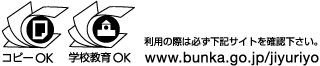  
この演習は、大学講義科目「画像工学」の講義資料として作成されています。  
このipynbファイルは、学校教育のための非営利目的利用を認めます。[https://www.bunka.go.jp/jiyuriyo](https://www.bunka.go.jp/jiyuriyo)  
この演習で使用している画像ファイル（imagefiles.zip、及び、imagefiles.zip 内の個々のファイル）については再配布を禁止します。